In [3]:
MODEL_PATH=r"C:\Users\Stefano\Documents\Uni\UniLu\CVIA\spacecraft_eta25\models\segmentation\segformer\CustomLoss\SegformerCropped200Epochs100Percent\best_model.pth"

In [4]:
import torch
import numpy as np
import cv2
import os
from tqdm import tqdm
import segmentation_models_pytorch as smp
from torch.utils.data import DataLoader
from pathlib import Path
import sys
utils_path = r"../../../Utils"
sys.path.append(str(utils_path))
from utils import *

ROOT_DIR =  r"../../../../data/spark_cropped" 


# --- UTILS PER TASK-2 ---

def get_iou(pred, gt, class_idx):
    """Compute IoU for the specified class."""
    intersection = np.logical_and(pred == class_idx, gt == class_idx).sum()
    union = np.logical_or(pred == class_idx, gt == class_idx).sum()
    if union == 0:
        return None  # Classe non presente
    return intersection / union

def compute_success_rate(iou_list):
    """Calcola la media della percentuale di immagini sopra le soglie 0.5:0.05:0.95."""
    thresholds = np.arange(0.5, 1.0, 0.05)
    valid_ious = [iou for iou in iou_list if iou is not None]
    if not valid_ious:
        return 0.0
    
    successes = []
    for t in thresholds:
        rate = np.mean([1.0 if iou >= t else 0.0 for iou in valid_ious])
        successes.append(rate)
    return np.mean(successes)

# --- SETUP MODELLO E DATI ---
class_map = {
    'VenusExpress': 0, 'Cheops': 1, 'LisaPathfinder': 2, 'ObservationSat1': 3,
    'Proba2': 4, 'Proba3': 5, 'Proba3ocs': 6, 'Smart1': 7, 'Soho': 8, 'XMM Newton': 9
}

Found Pytorch


In [ ]:

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
#MODEL LOADING
model = smp.Segformer(encoder_name="mit_b0", encoder_weights=None, in_channels=3, classes=3).to(DEVICE)
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

#VALIDATION DATASET AND DATALOADER
val_ds = ResizedSPARKDataset(class_map=class_map, root_dir=ROOT_DIR, split='val', target_size=(512, 512))
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False,num_workers=8)

all_body_ious = []
all_panels_ious = []


In [ ]:

print("Starting Validation for Task-2 Score...")

with torch.no_grad():
    for batch in tqdm(val_loader):
        imgs = batch['img'].to(DEVICE)
        masks_rgb = batch['mask'] # GT [1, 3, 512, 512]
        
        # 1. Predictions
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()[0] # [512, 512]
        
        # 2. Ground Truth
        # Mapping RGB -> Class Indices (Old logic)
        gt_mask = np.zeros((512, 512), dtype=np.uint8)
        gt_mask[masks_rgb[0, 0, :, :] > 0] = 1 # Red -> Body
        gt_mask[masks_rgb[0, 2, :, :] > 0] = 2 # Blue -> Panels
        
        # 3. Task-2 Logic: Check panel area
        body_area = (gt_mask == 1).sum()
        panel_area = (gt_mask == 2).sum()
        
        # Compute IoU Body
        iou_b = get_iou(preds, gt_mask, 1)
        if iou_b is not None:
            all_body_ious.append(iou_b)
            
        # Compute IoU Panels with 5% condition
        if panel_area > 0:
            # Only consider if panels cover at least 5% of body area (Codabench rule)
            if (panel_area / body_area) >= 0.05:
                iou_p = get_iou(preds, gt_mask, 2)
                all_panels_ious.append(iou_p if iou_p is not None else 0.0)

# --- Final results ---

score_body = compute_success_rate(all_body_ious)
score_panels = compute_success_rate(all_panels_ious)
final_score = (score_body + score_panels) / 2

print("\n" + "="*30)
print(f"RESULTS ON VALIDATION SET")
print(f"Mean IoU Body:   {np.mean(all_body_ious):.4f}")
print(f"Mean IoU Panels: {np.mean(all_panels_ious):.4f}")
print("-" * 30)
print(f"Task-2 Score (Body):   {score_body:.4f}")
print(f"Task-2 Score (Panels): {score_panels:.4f}")
print(f"--> FINAL SCORE:      {final_score:.4f} <--")
print("="*30)

# Mask Conversion Debugging

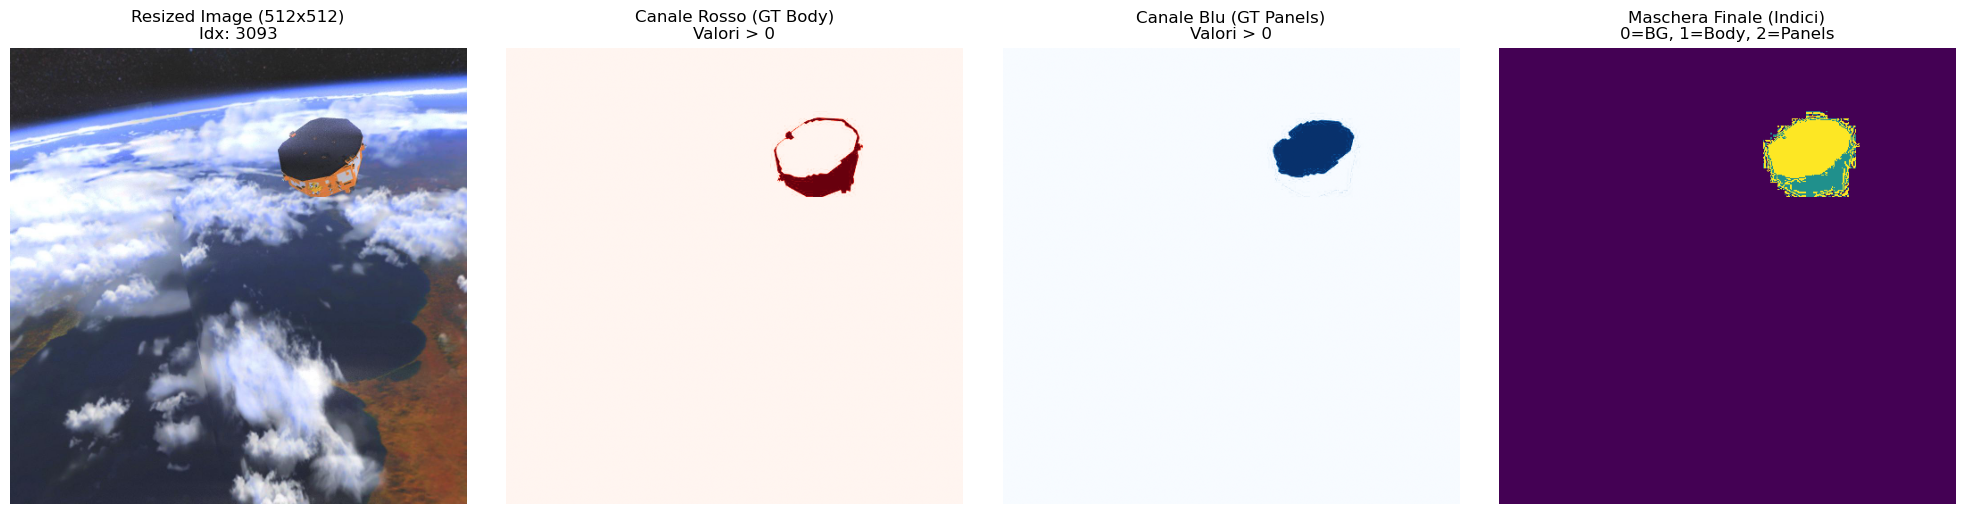

Max valore canale Rosso: 1.0000
Max valore canale Blu: 1.0000


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def inspect_resized_data(dataset, idx=None):
    if idx is None:
        idx = np.random.randint(len(dataset))
    
    # 1 Load sample
    sample = dataset[idx]
    img = sample['img'].permute(1, 2, 0).numpy()
    mask_rgb = sample['mask'] # Tensor [3, 512, 512]
    
    # 2. Mapping RGB mask to class indices (Old logic)
    masks_idx = torch.zeros((512, 512), dtype=torch.long)
    masks_idx[(mask_rgb[0, :, :] > 0)] = 1  # Rosso -> Body
    masks_idx[(mask_rgb[2, :, :] > 0)] = 2  # Blu -> Panels
    
    # 3. Visualization
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    # Original Image
    axes[0].imshow(img)
    axes[0].set_title(f"Resized Image (512x512)\nIdx: {idx}")
    
    # Red channel (Body)
    axes[1].imshow(mask_rgb[0].numpy(), cmap='Reds')
    axes[1].set_title("Red Channel (GT Body)\nValori > 0")
    
    # Blue channel (Panels)
    axes[2].imshow(mask_rgb[2].numpy(), cmap='Blues')
    axes[2].set_title("Blue Channel (GT Panels)\nValori > 0")
    
    # Final Mask (what the Loss sees)
    axes[3].imshow(masks_idx.numpy(), cmap='viridis')
    axes[3].set_title("Final Mask (Indices)\n0=BG, 1=Body, 2=Panels")
    
    for ax in axes:
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

    # Value debug
    print(f"Max value red channel: {mask_rgb[0].max():.4f}")
    print(f"Max value blue channel: {mask_rgb[2].max():.4f}")


inspect_resized_data(val_ds)

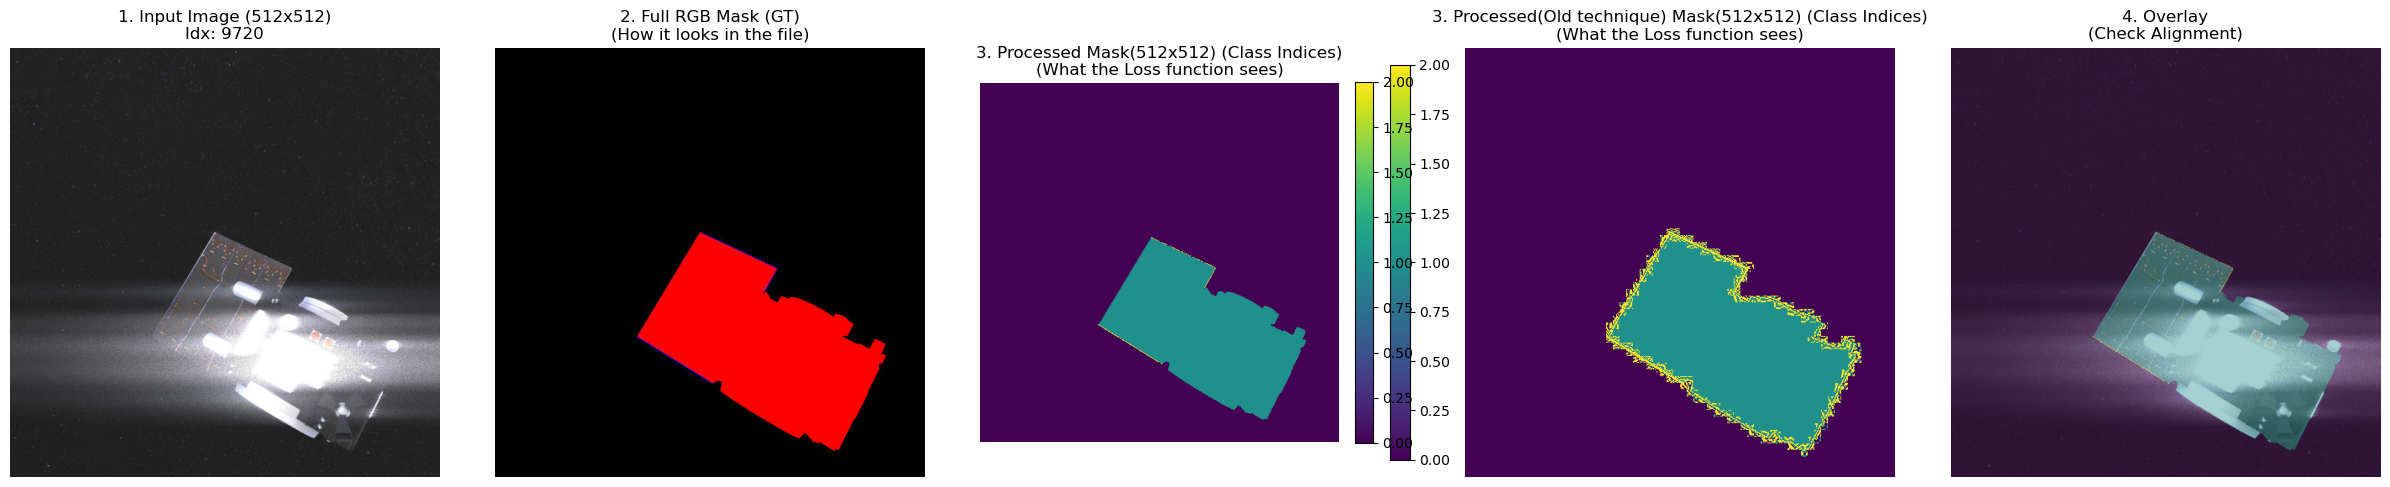

--- Debug Info (Idx: 9720) ---
Pixel con sovrapposizione Rosso/Blu: 3408
⚠️ Warning: There are 3408 pixel where both body and panels are active.
Binary logic assigns those to panels.
--- Debug Info (Idx: 9720) ---
Pixel con sovrapposizione Rosso/Blu: 3408
⚠️ Warning: There are 3408 pixel where both body and panels are active.
Binary logic assigns those to panels.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def inspect_full_data(dataset, idx=None):
    if idx is None:
        idx = np.random.randint(len(dataset))
    
    # 1.Load sampe dataset
    sample = dataset[idx]
    img = sample['img'].permute(1, 2, 0).cpu().numpy()
    mask_rgb = sample['mask'] # Tensor [3, 512, 512]
    
    # 2. Convert  RGB channels  
    #This is the mask that the model "sees" as target during the loss
    threshold = 0.5 if mask_rgb.max() <= 1.0 else 127

    red_ch = mask_rgb[0, :, :]   #  Red channel (Body)
    blue_ch = mask_rgb[2, :, :]  # Blue channel (Panels)

    # 2. Init the background
    masks_idx = torch.zeros(red_ch.shape, dtype=torch.long, device=mask_rgb.device)
    # 3. Process Body(1)
    masks_idx[(red_ch > threshold) & (red_ch >= blue_ch)] = 1 # using new logic : treshold + dominance

    #Process panels (2)
    masks_idx[(blue_ch > threshold) & (blue_ch > red_ch)] = 2
    

    # Using old technique
    masks_idx_old = torch.zeros((512, 512), dtype=torch.long)
    masks_idx_old[(mask_rgb[0, :, :] > 0)] = 1  # Red -> Body
    masks_idx_old[(mask_rgb[2, :, :] > 0)] = 2  # Blu -> Panels
    # 3. Visualize
    fig, axes = plt.subplots(1, 5, figsize=(24, 6))
    
    # A. Original image 
    axes[0].imshow(img)
    axes[0].set_title(f"1. Input Image ({red_ch.shape[0]}x{red_ch.shape[0]})\nIdx: {idx}")
    
    # B. GT original file
    axes[1].imshow(mask_rgb.permute(1, 2, 0).numpy())
    axes[1].set_title("2. Full RGB Mask (GT)\n(How it looks in the file)")
    
    # C. Processed GT
    im_idx = axes[2].imshow(masks_idx.numpy(), cmap='viridis')
    axes[2].set_title(f"3. Processed Mask({red_ch.shape[0]}x{red_ch.shape[0]}) (Class Indices)\n(What the Loss function sees)")
    plt.colorbar(im_idx, ax=axes[2], fraction=0.046, pad=0.04)
    # Processed GT with old logic
    im_idx_old = axes[3].imshow(masks_idx_old.numpy(), cmap='viridis')
    axes[3].set_title(f"3. Processed(Old technique) Mask({red_ch.shape[0]}x{red_ch.shape[0]}) (Class Indices)\n(What the Loss function sees)")
    plt.colorbar(im_idx_old, ax=axes[2], fraction=0.046, pad=0.04)
    
    # D. Overlay 
    
    axes[4].imshow(img)
    axes[4].imshow(masks_idx.numpy(), alpha=0.4, cmap='viridis') # Transparency
    axes[4].set_title("4. Overlay\n(Check Alignment)")
    
    for ax in axes:
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

    #Border analysis
    overlap = (mask_rgb[0] > 0) & (mask_rgb[2] > 0)
    num_overlap = overlap.sum().item()
    
    print(f"--- Debug Info (Idx: {idx}) ---")
    print(f"Pixel with overlap Red/Blu: {num_overlap}")
    if num_overlap > 0:
        print(f"⚠️ Warning: There are {num_overlap} pixel where both body and panels are active.")
        print("Binary logic assigns those to panels.")


        
    overlap = (mask_rgb[0] > 0) & (mask_rgb[2] > 0)
    num_overlap = overlap.sum().item()
    
    print(f"--- Debug Info (Idx: {idx}) ---")
    print(f"Pixel with overlap Red/BlU {num_overlap}")
    if num_overlap > 0:
        print(f"⚠️ Warning: There are {num_overlap} pixel where both body and panels are active.")
        print("Binary logic assigns those to panels.")

# Esecuzione
inspect_full_data(val_ds)

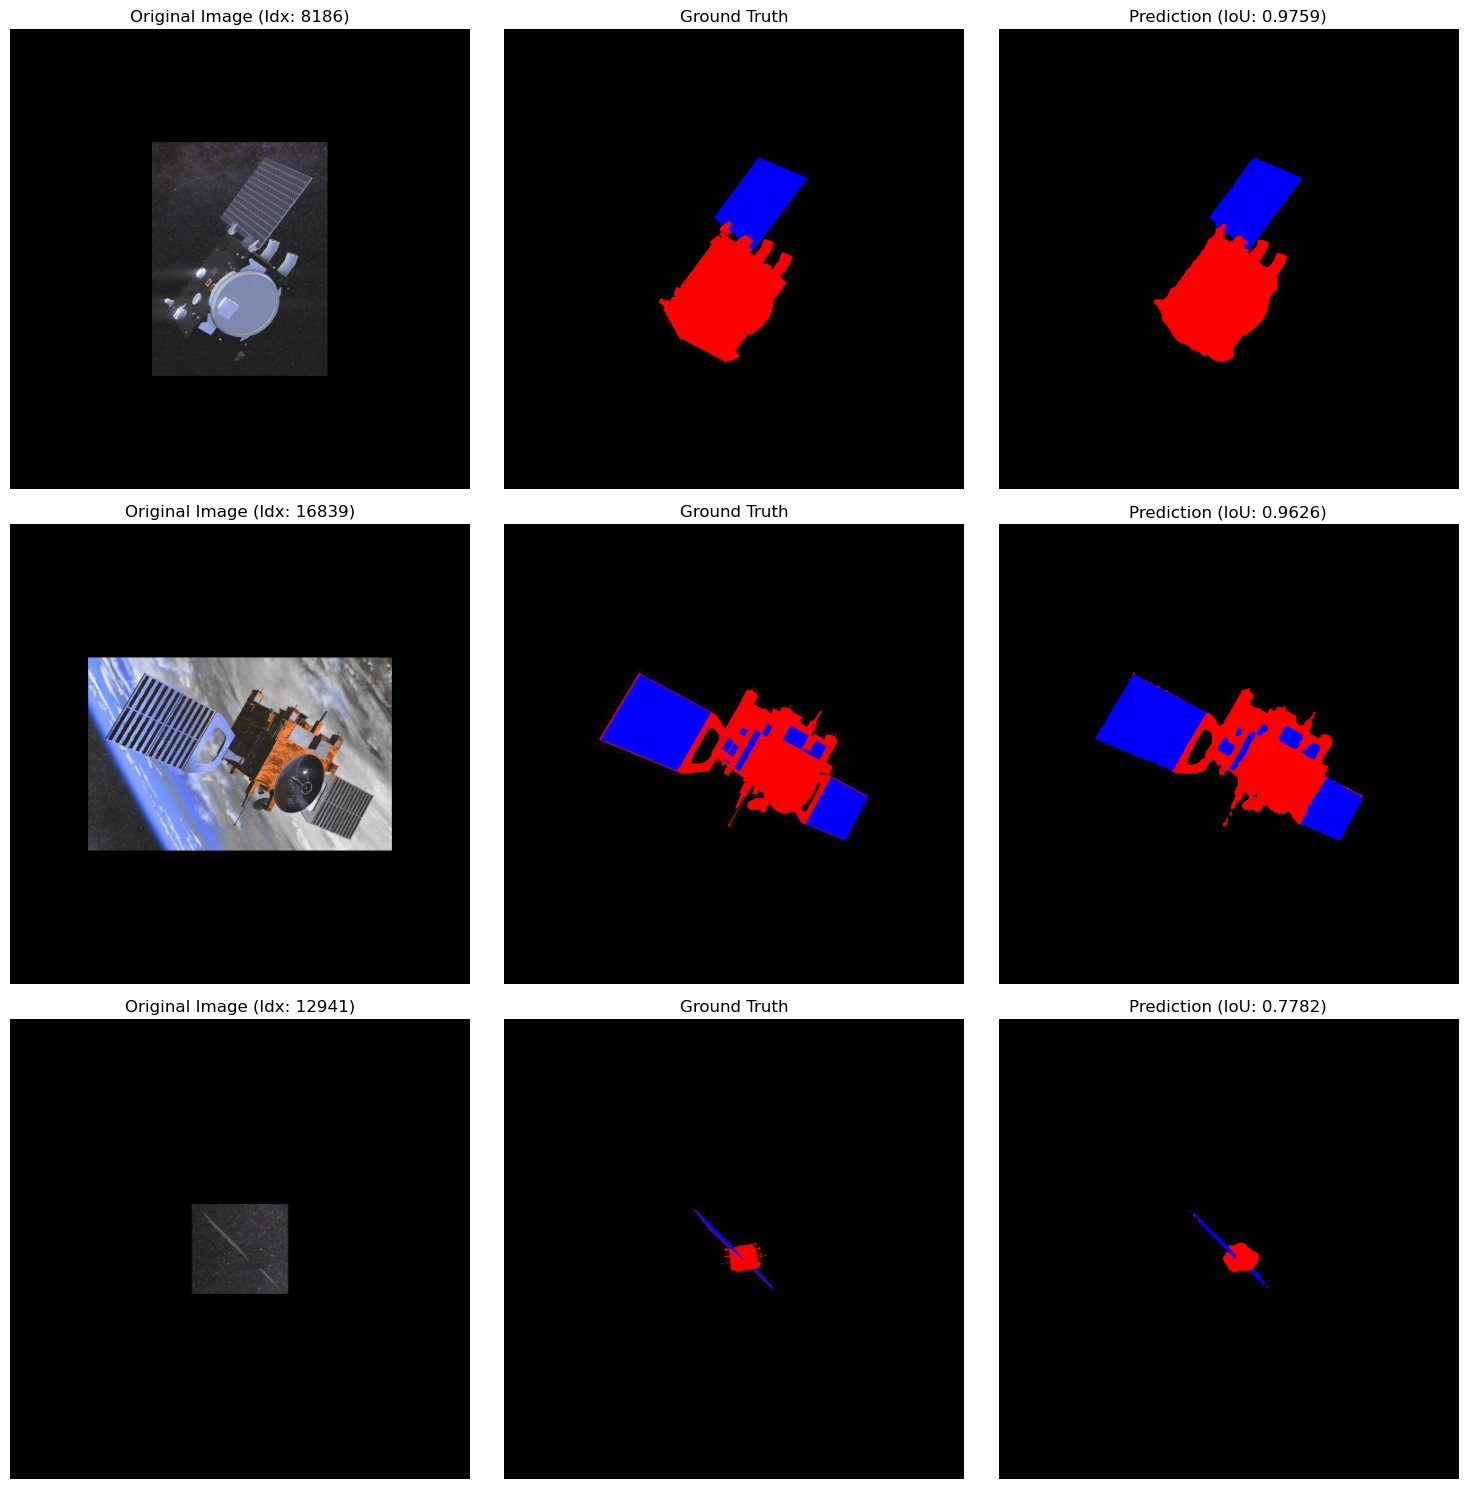

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_predictions(model, dataset, num_samples=5, device="cuda"):
    model.eval()
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))
    
    #  Color map
    color_map = np.array([
        [0, 0, 0],      # Background
        [255, 0, 0],    # Body (Red)
        [0, 0, 255]     # Panel (Blue)
    ])

    with torch.no_grad():
        for i, idx in enumerate(indices):
            sample = dataset[idx]
            img_tensor = sample['img'].unsqueeze(0).to(device)
            mask_rgb_gt = sample['mask'].permute(1, 2, 0).numpy() # GT 

            # Prediction
            outputs = model(img_tensor)
            pred = torch.argmax(outputs, dim=1).cpu().squeeze(0).numpy()
            
            # Transform prediction for visualization
            pred_rgb = color_map[pred]


            original_img = sample['img'].permute(1, 2, 0).cpu().numpy()
            threshold = 0.5 if mask_rgb_gt.max() <= 1.0 else 127

            red_ch = mask_rgb_gt[:, :, 0]   #  Red channel (Body)
            blue_ch = mask_rgb_gt[:, :, 2]  # Blue channel (Panels)

            # 2. Init the background
            gt_indices = torch.zeros(red_ch.shape, dtype=torch.long, device=mask_rgb_gt.device)
            # 3. Process Body(1)
            gt_indices[(red_ch > threshold) & (red_ch >= blue_ch)] = 1 # using new logic : treshold + dominance
            #Process panels (2)
            gt_indices[(blue_ch > threshold) & (blue_ch > red_ch)] = 2


            gt_indices = gt_indices.cpu().numpy()
            
            intersection = np.logical_and(pred > 0, gt_indices > 0).sum()
            union = np.logical_or(pred > 0, gt_indices > 0).sum()
            iou = intersection / union if union > 0 else 0

            # Plotting
            axes[i, 0].imshow(original_img)
            axes[i, 0].set_title(f"Original Image (Idx: {idx})")
            axes[i, 0].axis('off')

            axes[i, 1].imshow(mask_rgb_gt)
            axes[i, 1].set_title("Ground Truth")
            axes[i, 1].axis('off')

            axes[i, 2].imshow(pred_rgb)
            axes[i, 2].set_title(f"Prediction (IoU: {iou:.4f})")
            axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

visualize_predictions(model, val_ds, num_samples=3, device=DEVICE)